# 🧠 Autoencoder dengan Dataset MNIST

**Dataset:** MNIST — 70.000 gambar digit tulisan tangan (0–9), grayscale 28×28 piksel  
**Metode:** Autoencoder (Vanilla / Fully Connected)  
**Framework:** PyTorch  

---

## 📌 Mengapa MNIST Cocok untuk Autoencoder?

| Alasan | Penjelasan |
|---|---|
| Sederhana | Grayscale 28×28 = 784 fitur, tidak butuh GPU besar |
| Benchmark klasik | Digunakan di ratusan paper Autoencoder |
| Visual | Hasil rekonstruksi mudah dievaluasi secara visual |
| Balanced | 10 kelas digit seimbang |

---

## 🏗️ Arsitektur Autoencoder

```
Input (784)  →  Encoder  →  Latent Space (32)  →  Decoder  →  Output (784)
                [784→256→128→64→32]               [32→64→128→256→784]
```

## 1️⃣ Import Library

In [12]:
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set seed untuk reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Library berhasil di-import')
print(f'🖥️  Device yang digunakan: {device}')

✅ Library berhasil di-import
🖥️  Device yang digunakan: cpu


In [13]:
# ✅ Install semua library yang dibutuhkan (jalankan sekali saja)
!pip install torch torchvision scikit-learn matplotlib numpy pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2️⃣ Load Dataset MNIST

Dataset MNIST akan di-download otomatis via `torchvision`. Dataset terdiri dari:
- **Train:** 60.000 gambar
- **Test:** 10.000 gambar
- **Ukuran gambar:** 28×28 piksel, grayscale

In [14]:
from torchvision import datasets, transforms

# Transform: ubah ke tensor dan normalisasi ke [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download & load dataset
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader
BATCH_SIZE = 256
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'✅ Dataset berhasil dimuat')
print(f'   Train : {len(train_dataset):,} sampel')
print(f'   Test  : {len(test_dataset):,} sampel')
print(f'   Ukuran gambar: 28×28 piksel (grayscale)')

✅ Dataset berhasil dimuat
   Train : 60,000 sampel
   Test  : 10,000 sampel
   Ukuran gambar: 28×28 piksel (grayscale)


## 3️⃣ Visualisasi Sampel Data

C:\Users\USER\AppData\Local\Temp\ipykernel_13124\2190278966.py:19: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


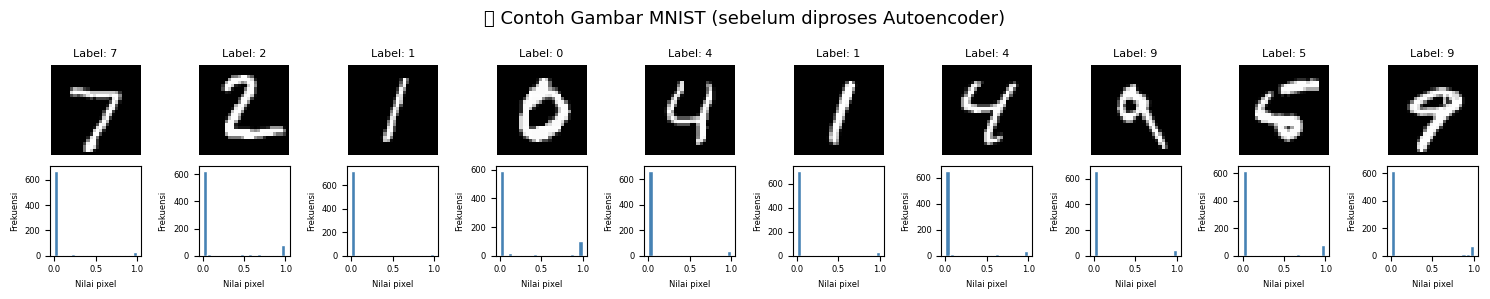

Shape tensor gambar: torch.Size([1, 28, 28])  →  (Channel, Tinggi, Lebar)


In [15]:
# Ambil 1 batch dari test loader
examples = iter(test_loader)
images, labels = next(examples)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
fig.suptitle('📷 Contoh Gambar MNIST (sebelum diproses Autoencoder)', fontsize=13)

for i in range(10):
    # Baris 1: gambar asli
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Label: {labels[i].item()}', fontsize=8)
    axes[0, i].axis('off')
    # Baris 2: distribusi pixel
    axes[1, i].hist(images[i].numpy().flatten(), bins=20, color='steelblue', edgecolor='white')
    axes[1, i].set_xlabel('Nilai pixel', fontsize=6)
    axes[1, i].set_ylabel('Frekuensi', fontsize=6)
    axes[1, i].tick_params(labelsize=6)

plt.tight_layout()
plt.show()
print(f'Shape tensor gambar: {images[0].shape}  →  (Channel, Tinggi, Lebar)')

## 4️⃣ Membangun Model Autoencoder

Arsitektur:
- **Encoder:** 784 → 256 → 128 → 64 → **32** (latent space)
- **Decoder:** 32 → 64 → 128 → 256 → **784**
- Aktivasi: `ReLU` di encoder/decoder tengah, `Sigmoid` di output (agar nilai [0,1])

In [16]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        
        # ENCODER: kompres gambar ke representasi kecil
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
            nn.ReLU()
        )
        
        # DECODER: rekonstruksi balik dari latent space
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()  # output dalam range [0, 1]
        )
    
    def forward(self, x):
        # Flatten gambar 28x28 → vektor 784
        x = x.view(x.size(0), -1)
        # Encode
        latent = self.encoder(x)
        # Decode
        reconstructed = self.decoder(latent)
        return reconstructed
    
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)


# Inisialisasi model
LATENT_DIM = 32
model = Autoencoder(latent_dim=LATENT_DIM).to(device)

# Hitung total parameter
total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model berhasil dibuat')
print(f'   Latent dimension : {LATENT_DIM}')
print(f'   Total parameter  : {total_params:,}')
print(f'\n📐 Arsitektur Model:')
print(model)

✅ Model berhasil dibuat
   Latent dimension : 32
   Total parameter  : 489,136

📐 Arsitektur Model:
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=784, bias=True)
    (7): Sigmoid()
  )
)


## 5️⃣ Training Autoencoder

In [17]:
# Loss function & optimizer
criterion = nn.MSELoss()          # Mean Squared Error untuk rekonstruksi
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20
train_losses = []
test_losses  = []

print('🚀 Mulai Training...')
print(f'   Epochs     : {EPOCHS}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Optimizer  : Adam (lr=0.001)')
print(f'   Loss       : MSE Loss')
print('-' * 50)

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        output = model(images)
        target = images.view(images.size(0), -1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation ---
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            output = model(images)
            target = images.view(images.size(0), -1)
            loss = criterion(output, target)
            running_test_loss += loss.item()
    
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:2d}/{EPOCHS}]  Train Loss: {avg_train_loss:.6f}  |  Test Loss: {avg_test_loss:.6f}')

print('-' * 50)
print('✅ Training selesai!')

🚀 Mulai Training...
   Epochs     : 20
   Batch size : 256
   Optimizer  : Adam (lr=0.001)
   Loss       : MSE Loss
--------------------------------------------------
Epoch [ 1/20]  Train Loss: 0.073284  |  Test Loss: 0.055475
Epoch [ 5/20]  Train Loss: 0.028395  |  Test Loss: 0.027025
Epoch [10/20]  Train Loss: 0.021003  |  Test Loss: 0.020180
Epoch [15/20]  Train Loss: 0.017027  |  Test Loss: 0.016408
Epoch [20/20]  Train Loss: 0.014644  |  Test Loss: 0.014342
--------------------------------------------------
✅ Training selesai!


## 6️⃣ Visualisasi Loss Curve

C:\Users\USER\AppData\Local\Temp\ipykernel_13124\3655041153.py:9: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


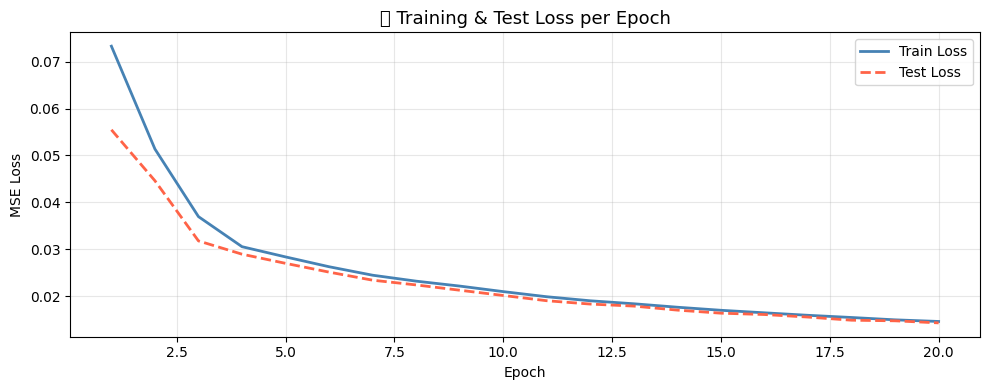

Final Train Loss : 0.014644
Final Test Loss  : 0.014342


In [18]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='steelblue', linewidth=2)
plt.plot(range(1, EPOCHS+1), test_losses,  label='Test Loss',  color='tomato',    linewidth=2, linestyle='--')
plt.title('📉 Training & Test Loss per Epoch', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final Train Loss : {train_losses[-1]:.6f}')
print(f'Final Test Loss  : {test_losses[-1]:.6f}')

## 7️⃣ Visualisasi Hasil Rekonstruksi

Bandingkan gambar **asli** vs gambar yang **direkonstruksi** oleh Autoencoder.

C:\Users\USER\AppData\Local\Temp\ipykernel_13124\613748010.py:35: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


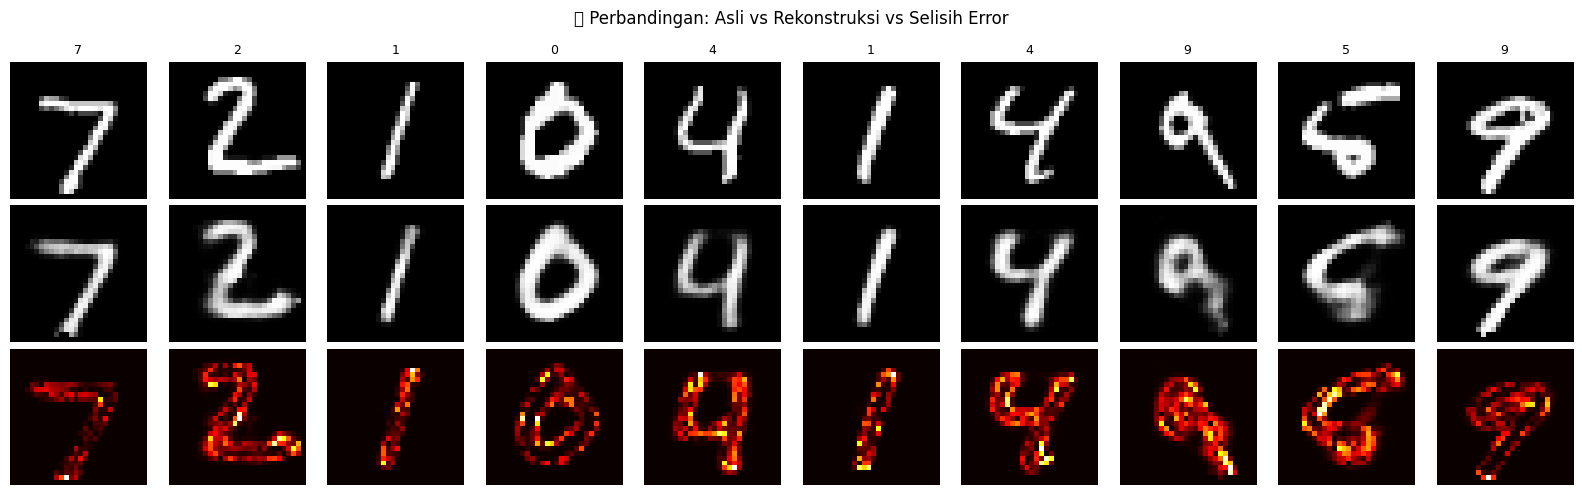

In [19]:
model.eval()
with torch.no_grad():
    test_images, test_labels = next(iter(test_loader))
    test_images = test_images.to(device)
    reconstructed = model(test_images)
    reconstructed = reconstructed.view(-1, 1, 28, 28).cpu()
    test_images = test_images.cpu()

n = 10
fig, axes = plt.subplots(3, n, figsize=(16, 5))
fig.suptitle('🔄 Perbandingan: Asli vs Rekonstruksi vs Selisih Error', fontsize=12)

for i in range(n):
    orig = test_images[i].squeeze().numpy()
    recon = reconstructed[i].squeeze().numpy()
    diff  = np.abs(orig - recon)
    
    # Baris 1: Gambar asli
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'{test_labels[i].item()}', fontsize=9)
    axes[0, i].axis('off')
    
    # Baris 2: Rekonstruksi
    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].axis('off')
    
    # Baris 3: Selisih error
    axes[2, i].imshow(diff, cmap='hot')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Asli', fontsize=9)
axes[1, 0].set_ylabel('Rekonstruksi', fontsize=9)
axes[2, 0].set_ylabel('Error', fontsize=9)

plt.tight_layout()
plt.show()

## 8️⃣ Visualisasi Latent Space (2D dengan t-SNE)

Lihat bagaimana Autoencoder memisahkan setiap digit dalam ruang laten.

⏳ Menjalankan t-SNE (sekitar 30 detik)...


C:\Users\USER\AppData\Local\Temp\ipykernel_13124\3600332243.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 10)
C:\Users\USER\AppData\Local\Temp\ipykernel_13124\3600332243.py:38: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


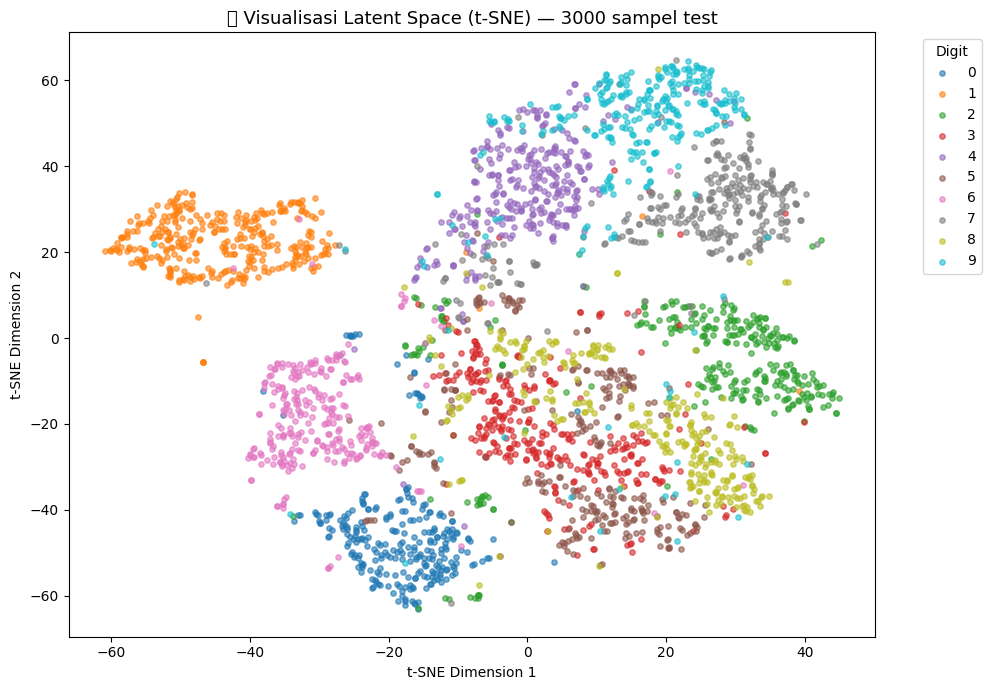

✅ Setiap warna mewakili satu digit — cluster yang bagus = representasi latent yang baik!


In [20]:
from sklearn.manifold import TSNE

# Ambil 3000 sampel dari test set
model.eval()
all_latent = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        latent = model.encode(images).cpu().numpy()
        all_latent.append(latent)
        all_labels.append(labels.numpy())
        if len(np.concatenate(all_labels)) >= 3000:
            break

latent_array = np.concatenate(all_latent)[:3000]
label_array  = np.concatenate(all_labels)[:3000]

# Reduksi ke 2D dengan t-SNE
print('⏳ Menjalankan t-SNE (sekitar 30 detik)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_array)

# Plot
colors = plt.cm.get_cmap('tab10', 10)
plt.figure(figsize=(10, 7))
for digit in range(10):
    idx = label_array == digit
    plt.scatter(latent_2d[idx, 0], latent_2d[idx, 1],
                c=[colors(digit)], label=str(digit),
                alpha=0.6, s=15)

plt.title('🗺️ Visualisasi Latent Space (t-SNE) — 3000 sampel test', fontsize=13)
plt.legend(title='Digit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.show()
print('✅ Setiap warna mewakili satu digit — cluster yang bagus = representasi latent yang baik!')

## 9️⃣ Evaluasi Model

In [21]:
from sklearn.metrics import mean_squared_error

model.eval()
all_orig   = []
all_recon  = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        output = model(images)
        all_orig.append(images.view(images.size(0), -1).cpu().numpy())
        all_recon.append(output.cpu().numpy())

orig_arr  = np.concatenate(all_orig)
recon_arr = np.concatenate(all_recon)

# Metrik
mse  = mean_squared_error(orig_arr, recon_arr)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(orig_arr - recon_arr))

# PSNR
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

print('📊 HASIL EVALUASI AUTOENCODER pada MNIST Test Set')
print('=' * 45)
print(f'  MSE  (Mean Squared Error)    : {mse:.6f}')
print(f'  RMSE (Root MSE)              : {rmse:.6f}')
print(f'  MAE  (Mean Absolute Error)   : {mae:.6f}')
print(f'  PSNR (Peak Signal-to-Noise)  : {psnr:.2f} dB')
print(f'  Latent Dimension             : {LATENT_DIM}')
print(f'  Compression Ratio            : 784/{LATENT_DIM} = {784/LATENT_DIM:.1f}x')
print('=' * 45)
print(f'\n💡 Interpretasi:')
print(f'   PSNR > 20 dB → rekonstruksi cukup baik')
print(f'   PSNR > 30 dB → rekonstruksi sangat baik')

📊 HASIL EVALUASI AUTOENCODER pada MNIST Test Set
  MSE  (Mean Squared Error)    : 0.014381
  RMSE (Root MSE)              : 0.119921
  MAE  (Mean Absolute Error)   : 0.042605
  PSNR (Peak Signal-to-Noise)  : 18.42 dB
  Latent Dimension             : 32
  Compression Ratio            : 784/32 = 24.5x

💡 Interpretasi:
   PSNR > 20 dB → rekonstruksi cukup baik
   PSNR > 30 dB → rekonstruksi sangat baik


## 🔟 Simpan Model

In [22]:
# Simpan model
torch.save(model.state_dict(), 'autoencoder_mnist.pth')
print('✅ Model disimpan sebagai: autoencoder_mnist.pth')

# Cara load kembali:
# model_loaded = Autoencoder(latent_dim=32)
# model_loaded.load_state_dict(torch.load('autoencoder_mnist.pth'))
# model_loaded.eval()
print('\n📌 Untuk load model kembali:')
print('   model = Autoencoder(latent_dim=32)')
print('   model.load_state_dict(torch.load("autoencoder_mnist.pth"))')

✅ Model disimpan sebagai: autoencoder_mnist.pth

📌 Untuk load model kembali:
   model = Autoencoder(latent_dim=32)
   model.load_state_dict(torch.load("autoencoder_mnist.pth"))


---

## 📋 Ringkasan

| Komponen | Detail |
|---|---|
| Dataset | MNIST (60K train, 10K test) |
| Input size | 784 (28×28 piksel) |
| Latent size | 32 (kompresi ~24.5x) |
| Epochs | 20 |
| Optimizer | Adam (lr=0.001) |
| Loss | MSE Loss |
| Evaluasi | MSE, RMSE, MAE, PSNR |

### 💡 Eksperimen Lanjutan
- Coba ubah `LATENT_DIM` ke 2, 8, 64, 128 — lihat pengaruhnya ke kualitas rekonstruksi
- Tambahkan **noise** ke input untuk melatih **Denoising Autoencoder**
- Ganti arsitektur ke **Convolutional Autoencoder** untuk hasil lebih tajam
- Coba **Variational Autoencoder (VAE)** untuk generate gambar baru